In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import seaborn as sns

# Networks Basics

Text(0.5, 1.0, 'Simple Graph')

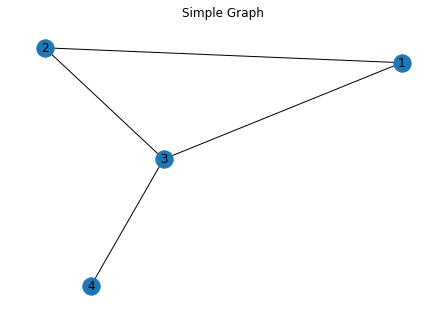

In [2]:
'''
First let's create a simple network. We define the edges, then graph
'''
network = nx.Graph()

edges = [(1,2), (2,3), (1,3), (3,4)]  # This automatically creates nodes 1,2,3,4

network.add_edges_from(edges)
nx.draw(network, with_labels=True)
plt.title('Simple Graph')

(-0.6575000823289163,
 1.1575000078231097,
 -1.0478907761761622,
 1.0478907563079471)

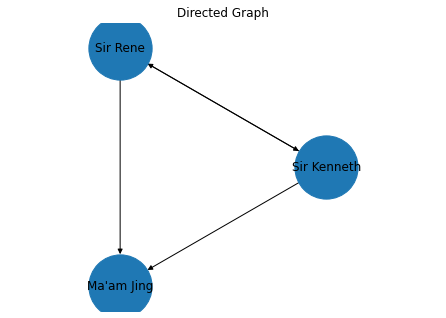

In [3]:
directed = nx.DiGraph()           # create a directed graph

directed.add_node('Sir Kenneth')
directed.add_node('Sir Rene')
directed.add_node("Ma'am Jing")   # add nodes

directed.add_edge('Sir Kenneth', 'Sir Rene')
directed.add_edge('Sir Rene', 'Sir Kenneth')
directed.add_edge('Sir Kenneth', "Ma'am Jing")
directed.add_edge('Sir Rene', "Ma'am Jing")    # add edges, directional

nx.draw_circular(directed, node_size = 4000, with_labels = True)
plt.title('Directed Graph')
plt.axis('equal')


# ER (Erdos-Renyi) Graph
An ER graph can refer to two models namely $G(n,M)$ or $G(n,p)$. <br>
    1. In the $G(n,M)$ model, a graph is chosen uniformly at random based on the collection of possible graphs that can exist given the nodes $n$ and edges $M$. The nodes are labeled, so permuting them yields distinct graphs. <br>
    2. In the $G(n,p)$ model, a graph is generated by connecting nodes based on a probability $p$. Each edge is included independently of any other edge. The probability then of generating a certain graph that has $n$ nodes and $M$ edges is $$P = p^M (1-p)^{ \begin{pmatrix} n \\ 2  \end{pmatrix} - M}$$

In [4]:
def flip(p):
    return np.random.random() < p   # returns True with probability p

def all_pairs(nodes):                  # nodes is a list
    for x, y in enumerate(nodes):
        for i, j in enumerate(nodes):  # iterate through pairs of nodes
            if x < i:
                yield y, j             # list of all possible pairs as tuples
                
def connected_pairs(nodes, p):         # connects pairs of nodes in random
    for edge in all_pairs(nodes):
        if flip(p):
            yield edge    
            
def create_ER_graph(n, p):       # standard method to create graph
    graph = nx.Graph()
    nodes = range(n)
    graph.add_nodes_from(nodes)
    graph.add_edges_from(connected_pairs(nodes, p))
    
    return graph


Text(0.5, 1.0, 'Erdos-Renyi Graph: 15 nodes, $p =$ 0.2')

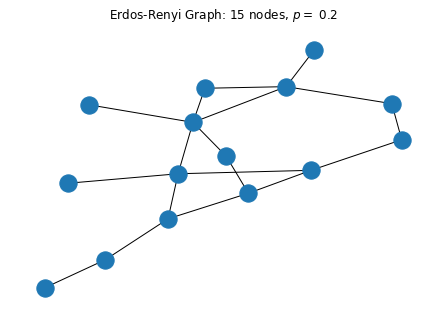

In [5]:
nodes = 15
probability = 0.2
ER = create_ER_graph(nodes, probability)
nx.draw(ER)
plt.title('Erdos-Renyi Graph: '+ str(nodes) + ' nodes, $p =$ ' + str(probability))

In [6]:
for x, y in enumerate(list(directed.nodes())):
    print(x, y)

# print(list(directed.nodes()))

friends = all_pairs(list(directed.nodes()))

for i in friends:
    print(i)

0 Sir Kenneth
1 Sir Rene
2 Ma'am Jing
('Sir Kenneth', 'Sir Rene')
('Sir Kenneth', "Ma'am Jing")
('Sir Rene', "Ma'am Jing")


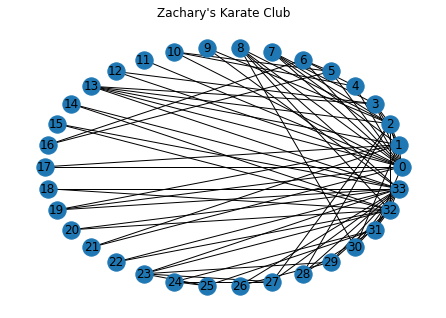

In [7]:
karate = nx.karate_club_graph()   # weighted graph, read context on Wikipedia it's kinda funny

# print("Node Degree")
# for v in karate:
#     print(f"{v:4} {karate.degree(v, weight='weight'):6}")  # degree is number of adjacent nodes

nx.draw_circular(karate, with_labels = True)
plt.title("Zachary's Karate Club")
plt.show()



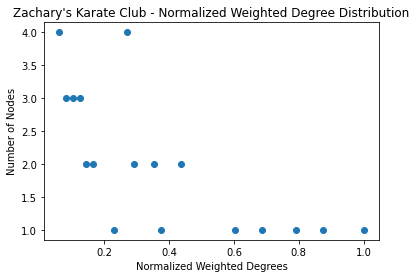

In [8]:
# Compute degrees
weighted_degrees = dict(karate.degree(weight='weight'))
max_weighted_degree = max(weighted_degrees.values())

# Normalize 
normalized_degrees = {node: degree / max_weighted_degree for node, degree in weighted_degrees.items()}

# Count number of nodes for each normalized weighted degree
degree_counts = {}
for degree in normalized_degrees.values():
    degree_counts[degree] = degree_counts.get(degree, 0) + 1

# Prepare data for scatter plot
x = list(degree_counts.keys())
y = list(degree_counts.values())

# Plot scatter plot
plt.scatter(x, y)
plt.xlabel('Normalized Weighted Degrees')
plt.ylabel('Number of Nodes')
plt.title("Zachary's Karate Club - Normalized Weighted Degree Distribution")
plt.show()

In [9]:
karate_adjacency = nx.adjacency_matrix(karate)
karate_adjacency_dense = karate_adjacency.todense()
# plt.imshow(karate_adjacency.todense())
print(karate_adjacency_dense)

[[0 4 5 ... 2 0 0]
 [4 0 6 ... 0 0 0]
 [5 6 0 ... 0 2 0]
 ...
 [2 0 0 ... 0 4 4]
 [0 0 2 ... 4 0 5]
 [0 0 0 ... 4 5 0]]


C:\Users\Edneil\AppData\Local\Temp\ipykernel_18384\430389904.py:1: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  karate_adjacency = nx.adjacency_matrix(karate)


# Networks Based on Position 

In [10]:
badlands = dict(BadwaterBasin=(-74,43),
                Dustbowl=(-71,42),
                GravelPit=(-74, 41),
                Teufort=(-74,40),
                Well=(-75, 40))   # these are TF2 maps in the badlands region
# badlands['Teufort']

badlands_position_graph = nx.Graph()
badlands_position_graph.add_nodes_from(badlands)
badlands_position_graph.nodes()

NodeView(('BadwaterBasin', 'Dustbowl', 'GravelPit', 'Teufort', 'Well'))

In [11]:
'''
Now, create another dictionary on how long it takes the mercenaries to drive 
from one map to the next. 
'''
drive_times = {
    ('Dustbowl', 'GravelPit'): 3,
    ('Dustbowl', 'Teufort')  : 4,
    ('Dustbowl', 'BadwaterBasin') : 2, 
    ('GravelPit', 'Teufort'): 3, 
    ('BadwaterBasin', 'Well'): 5
}

for edge, weight in drive_times.items():
    badlands_position_graph.add_edge(edge[0], edge[1], weight=weight) # create weighted edges
    
badlands_position_graph.edges()

EdgeView([('BadwaterBasin', 'Dustbowl'), ('BadwaterBasin', 'Well'), ('Dustbowl', 'GravelPit'), ('Dustbowl', 'Teufort'), ('GravelPit', 'Teufort')])

Text(0.5, 1.0, 'Drive Times in the Badlands')

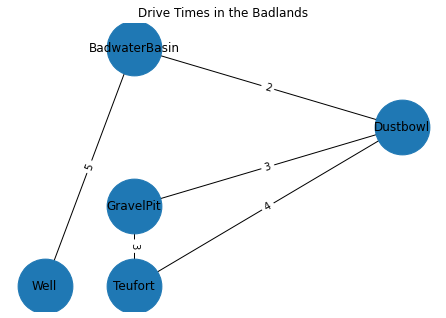

In [12]:
nx.draw(badlands_position_graph, badlands, with_labels=True, node_size=3000)
nx.draw_networkx_edge_labels(badlands_position_graph, badlands, edge_labels=drive_times)
plt.title('Drive Times in the Badlands')

C:\Users\Edneil\AppData\Local\Temp\ipykernel_18384\866560193.py:1: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  badlands_adj = nx.adjacency_matrix(badlands_position_graph)


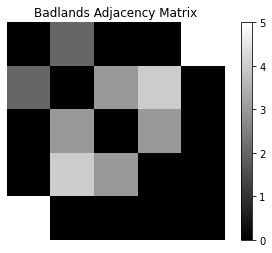

In [13]:
badlands_adj = nx.adjacency_matrix(badlands_position_graph)
badlands_adg_dense = badlands_adj.todense()

plt.title('Badlands Adjacency Matrix')
plt.imshow(badlands_adg_dense, cmap='gray')
plt.axis('off')
plt.colorbar()